In [1]:
#from google.colab import drive
#drive.mount('/content/drive')

In [2]:
#%cd "/content/drive/MyDrive/DIT/coursDeepLearning2026/Chapitre 3 cnn/conv-viz"

In [3]:
import os
print(os.getcwd())

c:\Users\mamad\Desktop\DIT\Deep_Learnig\conv-viz


##Couche de Convolution

Dans ce notebook, nous visualisons quatre sorties filtrées (ou cartes d’activation) d’une couche de convolution.

Dans cet exemple, nous définissons quatre filtres appliqués à une image d’entrée en initialisant les poids d’une couche de convolution.
Dans un CNN entraîné, les valeurs de ces poids seraient apprises automatiquement.

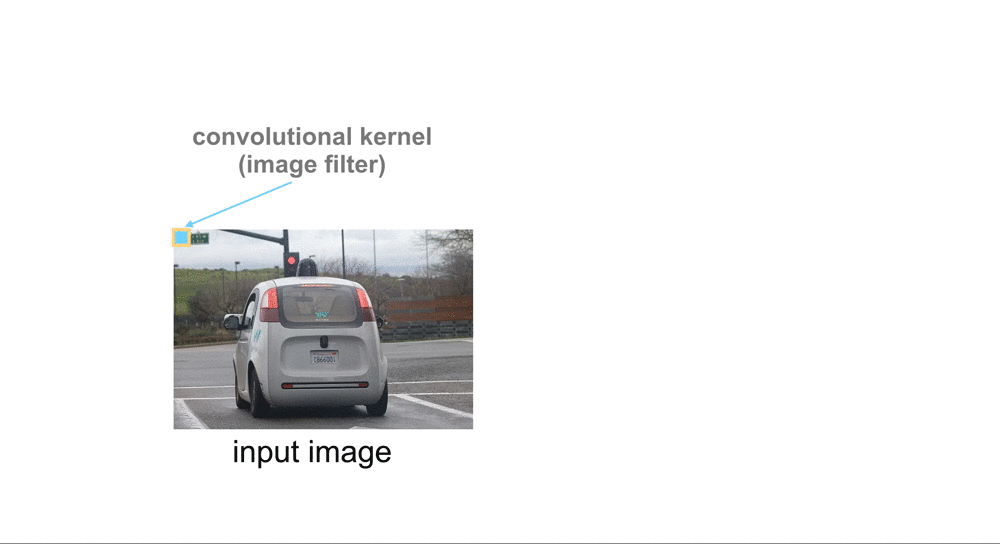

### Import the image

In [4]:
%pip install opencv-python

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


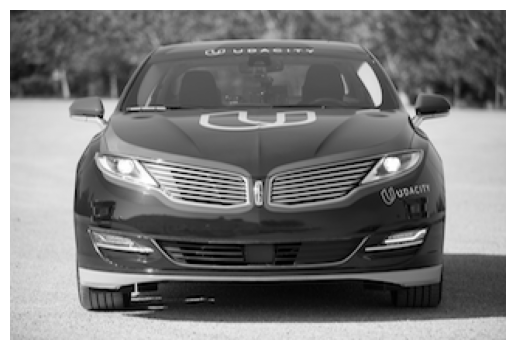

In [5]:
import cv2
import matplotlib.pyplot as plt
%matplotlib inline

# TODO: Feel free to try out your own images here by changing img_path
# to a file path to another image on your computer!
img_path = 'C:\\Users\\mamad\\Desktop\\DIT\\Deep_Learnig\\conv-viz\\data\\voiture_sdc.png'

# load color image
bgr_img = cv2.imread(img_path)
# convert to grayscale
gray_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2GRAY)

# normalize, rescale entries to lie in [0,1]
gray_img = gray_img.astype("float32")/255

# plot image
plt.imshow(gray_img, cmap='gray')
plt.axis("off")
plt.show()

### Define and visualize the filters

In [6]:
import numpy as np

## TODO: Feel free to modify the numbers here, to try out another filter!
filter_vals = np.array([[-1, -1, 1, 1], [-1, -1, 1, 1], [-1, -1, 1, 1], [-1, -1, 1, 1]])

print('Filter shape: ', filter_vals.shape)


Filter shape:  (4, 4)


In [7]:
# Defining four different filters,
# all of which are linear combinations of the `filter_vals` defined above

# define four filters
filter_1 = filter_vals
filter_2 = -filter_1
filter_3 = filter_1.T
filter_4 = -filter_3
# Stack them together in a (4, 4, 4) array
filters = np.array([filter_1, filter_2, filter_3, filter_4])

# For an example, print out the values of filter 1
print('Filter 1: \n', filter_1)

Filter 1: 
 [[-1 -1  1  1]
 [-1 -1  1  1]
 [-1 -1  1  1]
 [-1 -1  1  1]]


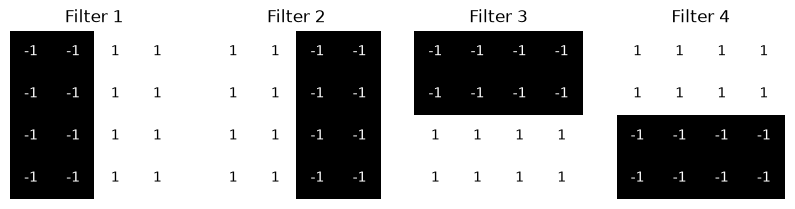

In [8]:
# visualize all four filters
from helpers import visualize_filters

visualize_filters(filters)

## Définir une couche de convolution

Les différentes couches qui composent un réseau de neurones sont documentées [ici](http://pytorch.org/docs/stable/nn.html).  
Pour un réseau de neurones convolutif, nous commençons par définir une **couche de convolution**.

Nous initialisons une seule couche de convolution de manière à ce qu’elle contienne tous les filtres que nous avons créés.

In [14]:
import torch

# Définit la couche de convolution, en supposant qu’il y a 4 filtres
# en niveaux de gris.
k_height = filters.shape[-1]
k_width = k_height
conv_layer = torch.nn.Conv2d(
    # Nombre de canaux en entrée. Ici, c’est une image en niveaux de gris, donc 1.
    # Si l’image était RGB, ce nombre serait 3.
    in_channels=1,
    # Nombre de cartes de caractéristiques en sortie.
    # Ici, nous utilisons 4 filtres, donc 4 cartes de sortie (une par filtre).
    out_channels=4,
    # Taille du noyau de convolution
    kernel_size=(k_height, k_width),
    stride=1,
    padding=0,
    # On ignore le biais pour le moment afin de pouvoir
    # initialiser facilement la couche avec nos filtres existants.
    bias=False,
)

# REMARQUE : l’étape suivante est uniquement utile pour ce tutoriel.
# Lorsqu’on utilise des couches de convolution dans un vrai modèle,
# on ne les initialise pas de cette manière.
# Nous allons donc initialiser les poids de la couche créée
# avec les filtres que nous avons déjà définis,
# afin d’observer comment PyTorch applique les filtres
# et quels sont leurs effets.
# Conversion des filtres en tenseurs PyTorch.
weights = (torch
           .from_numpy(filters)  # remarque : cela ne copie pas les données
           # Ajoute la dimension des canaux, de sorte que le tenseur ait la forme :
           # (n_filtres, n_canaux, hauteur_filtre, largeur_filtre)
           .unsqueeze(dim=1)
           # S’assure que le tenseur est bien de type FloatTensor (fp32)
           .type(torch.FloatTensor)
          )

# Associe les filtres aux poids de la couche.
# REMARQUE : on utilise torch.nn.Parameter pour que les poids
# soient reconnus comme paramètres du modèle.
conv_layer.weight = torch.nn.Parameter(weights)

In [10]:
gray_img

array([[0.13333334, 0.13333334, 0.11764706, ..., 0.24313726, 0.24313726,
        0.28627452],
       [0.16078432, 0.14117648, 0.13725491, ..., 0.23921569, 0.24705882,
        0.28627452],
       [0.1882353 , 0.17254902, 0.16862746, ..., 0.23529412, 0.24705882,
        0.27058825],
       ...,
       [0.7176471 , 0.72156864, 0.69411767, ..., 0.7921569 , 0.77254903,
        0.7411765 ],
       [0.7372549 , 0.74509805, 0.6784314 , ..., 0.77254903, 0.76862746,
        0.7490196 ],
       [0.72156864, 0.7411765 , 0.6745098 , ..., 0.7137255 , 0.7137255 ,
        0.6901961 ]], shape=(213, 320), dtype=float32)

And now let's see it in action on our input image:

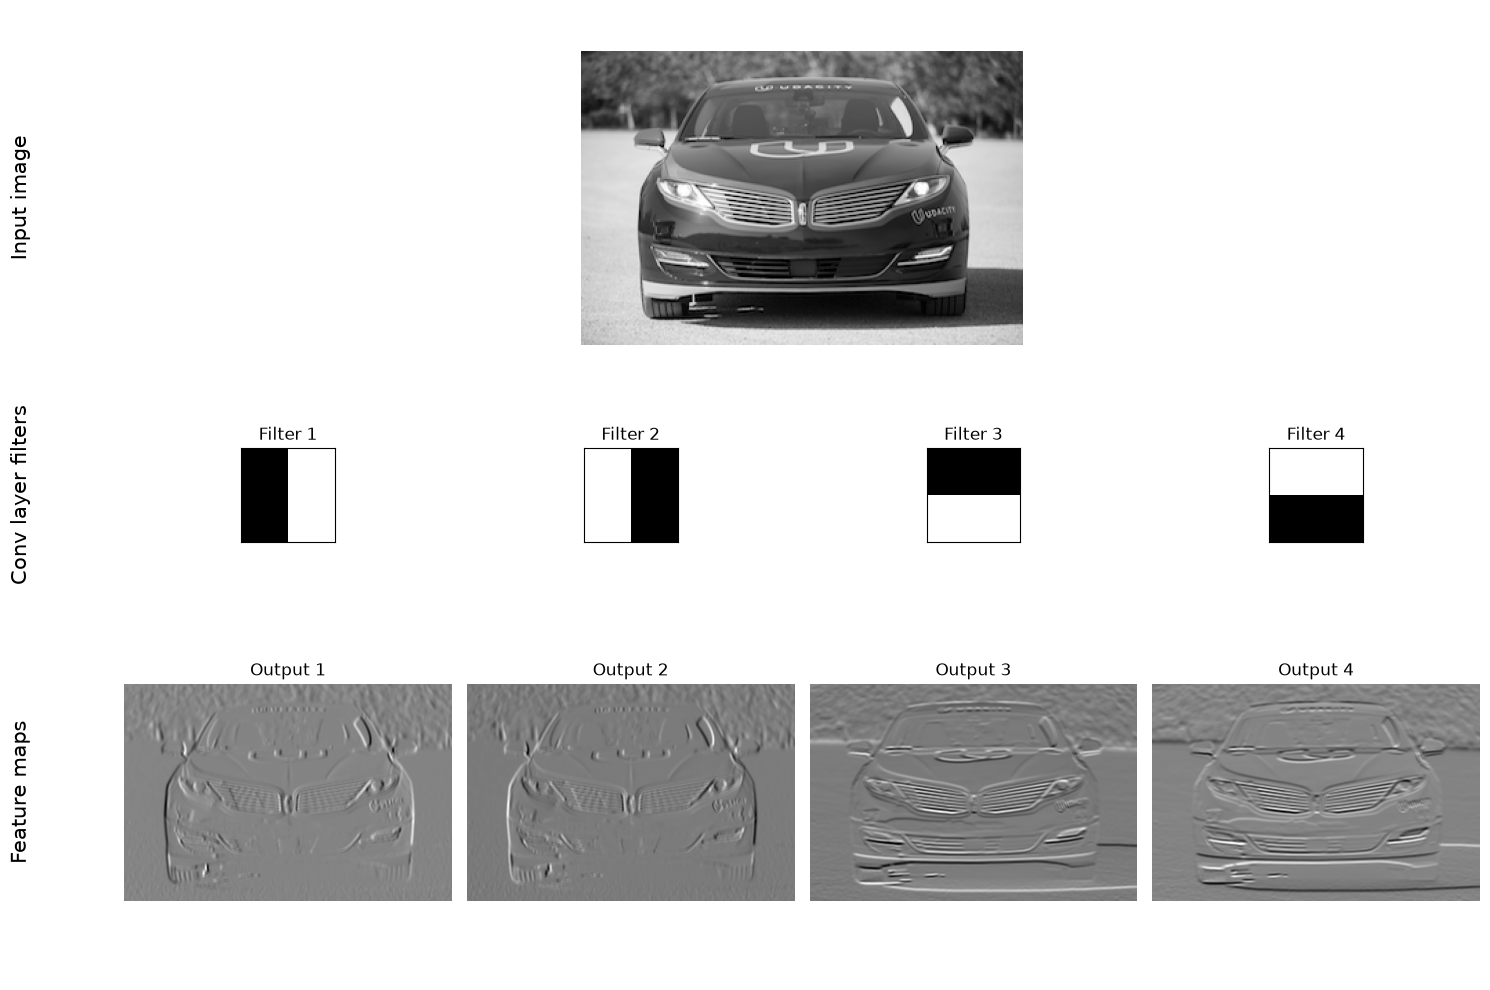

In [11]:
from helpers import show_feature_maps

# Convertit l’image en tenseur d’entrée (Tensor)
# avec la forme (n_éléments_par_lot, n_canaux, hauteur, largeur)
x = (
    torch.from_numpy(gray_img)
    # Ajoute une dimension pour le batch
    .unsqueeze(0)
    # Ajoute une dimension pour le nombre de canaux
    .unsqueeze(1)
)

# Fait passer l’image à travers la couche de convolution
# (ce qui appelle la méthode .forward de la couche)
feature_maps = conv_layer(x)

# Affiche les cartes de caractéristiques (feature maps)
# à l’aide de la fonction show_feature_maps
show_feature_maps(gray_img, feature_maps, filters)


#### Un modèle PyTorch : `__init__` et `forward`

Voyons maintenant comment utiliser une couche de convolution (ou toute autre couche) dans un modèle PyTorch.

Pour définir un réseau de neurones dans PyTorch, on définit les couches du modèle dans la fonction `__init__` et le comportement de propagation avant du réseau (c’est-à-dire l’application de ces couches initialisées à une entrée `x`) dans la fonction `forward` — appelée ainsi en référence au *forward pass* (par opposition à la rétropropagation).

Dans PyTorch, toutes les entrées sont converties en objets du type **Tensor**, un type de donnée similaire aux listes en Python.

Ci-dessous, nous définissons la structure d’une classe appelée `Net`, qui contient une couche de convolution semblable à celle utilisée précédemment.

In [12]:
# Définition d’un réseau de neurones avec une seule couche de convolution comportant quatre filtres
class Net(torch.nn.Module):

    # REMARQUE : nous pouvons ajouter n’importe quels paramètres au constructeur.
    # Dans ce cas, nous ajoutons en paramètre le tableau des filtres.
    def __init__(self, filters):

        super(Net, self).__init__()

        # Définition de la couche de convolution
        k_height = filters.shape[-1]
        k_width = k_height

        self.conv_layer = torch.nn.Conv2d(
            in_channels=1,
            out_channels=4,
            kernel_size=(k_height, k_width),
            stride=1,
            padding=0,
            bias=False
        )

        # Ajout d’une fonction d’activation,
        # par exemple une unité linéaire rectifiée (ReLU)
        self.relu = torch.nn.ReLU()

        # La partie suivante ne fait normalement pas partie d’un modèle PyTorch,
        # car les poids sont appris pendant l’entraînement.
        # Ici, nous les initialisons avec les filtres que nous avons définis manuellement,
        # comme précédemment.
        weights = (torch
                   .from_numpy(filters)
                   .unsqueeze(dim=1)
                   .type(torch.FloatTensor)
                  )
        self.conv_layer.weight = torch.nn.Parameter(weights)

    def forward(self, x):
        # Application de la couche de convolution
        x = self.conv_layer(x)

        # Application de la fonction d’activation
        x = self.relu(x)

        return x

# Instanciation du modèle et initialisation des poids
model = Net(filters)

# Affichage de la structure des couches du réseau
# RAPPEL : la sortie de l’instruction print suivante ne reflète pas nécessairement
# l’ordre d’exécution du réseau. En effet, les éléments sont affichés dans l’ordre
# où ils sont définis dans la méthode __init__, et non dans l’ordre
# où ils sont utilisés dans la méthode .forward.
# Essaie d’inverser la définition de self.relu et self.conv_layer dans __init__
# (sans modifier la méthode .forward) et observe le résultat de ce print.
print(model)

Net(
  (conv_layer): Conv2d(1, 4, kernel_size=(4, 4), stride=(1, 1), bias=False)
  (relu): ReLU()
)


#### Activation ReLU

Rappelons que la fonction d’activation appelée **ReLU** (*Rectified Linear Unit*) transforme toutes les valeurs de pixels négatives en **0** (noir), tout en laissant inchangées les valeurs positives.



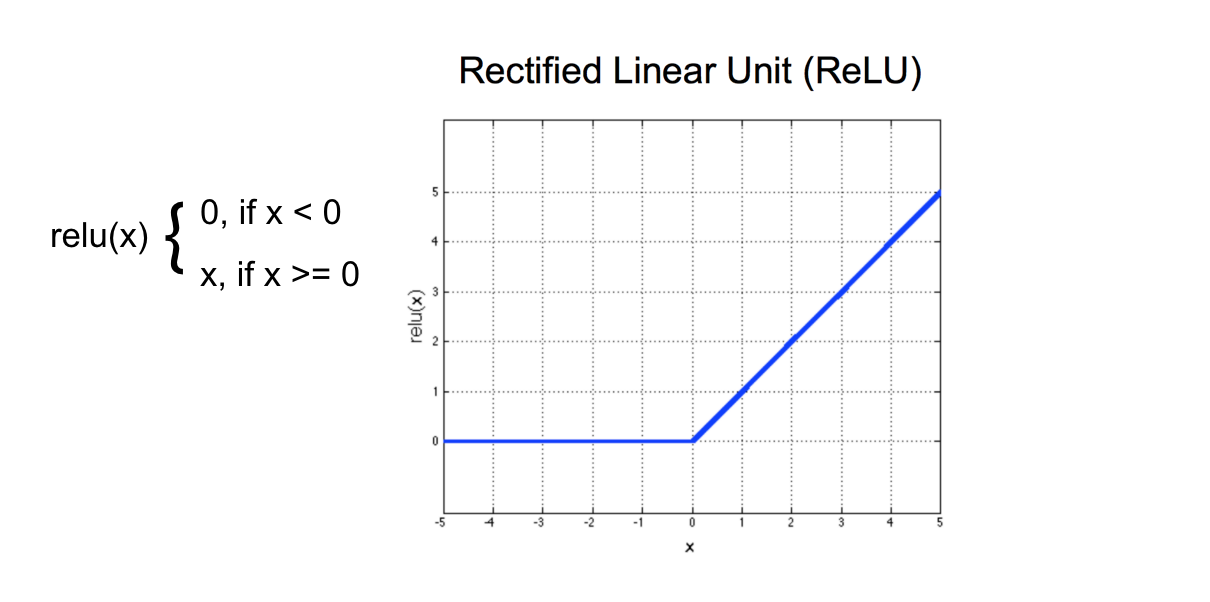

Visualisons maintenant ce qui se passe lorsqu’on applique cette fonction à nos cartes de caractéristiques  
(en les comparant avec celles que nous avions obtenues précédemment) :

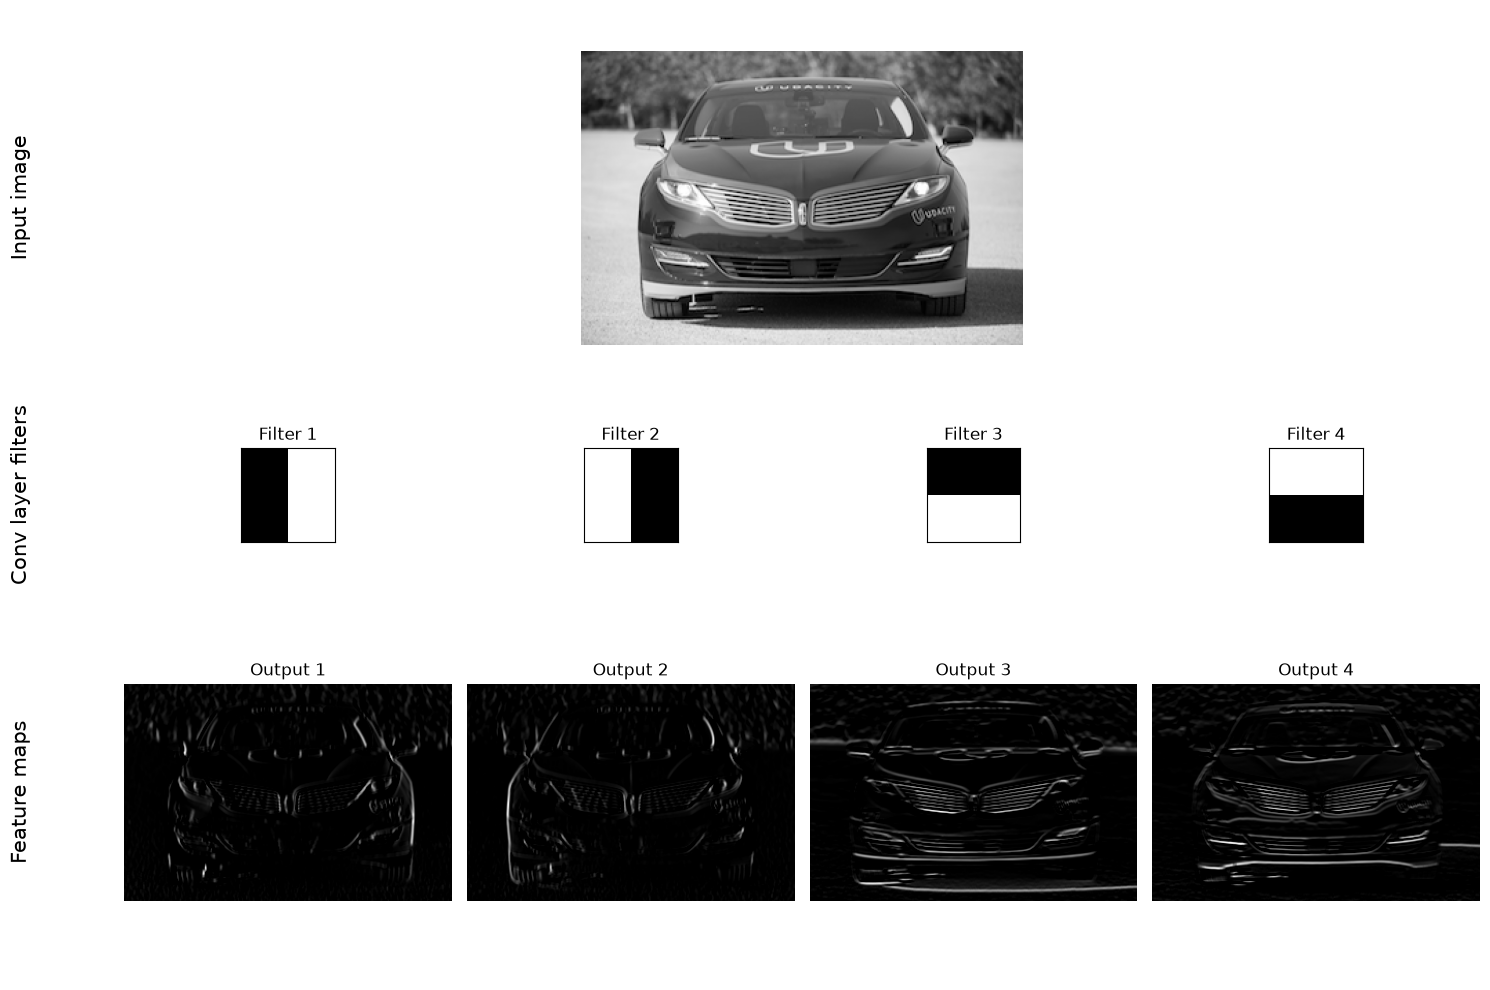

In [13]:
post_act_feature_maps = model(x)
show_feature_maps(gray_img, post_act_feature_maps, filters)

Comparez ces cartes de caractéristiques avec celles obtenues à partir de la couche de convolution sans activation.  
On peut immédiatement constater qu’appliquer **ReLU** revient à imposer un **seuil strict** sur nos cartes de caractéristiques : seules les arêtes les plus marquées sont conservées, tout le reste devient nul.